In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Folder where every chart is saved, so the Quarto report can use them
FIG_DIR = "../report/figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
national_df = pd.read_csv(
    "../data/clean/national_clean.csv",
    dtype={"fips": str}
)

state_df = pd.read_csv(
    "../data/clean/state_clean.csv",
    dtype={"fips": str}
)

county_df = pd.read_csv(
    "../data/clean/county_clean.csv",
    dtype={"fips": str}
)

## 9. Does OM Spending Differ by Medicaid Eligibility Share in Rural and Urban Counties?

Compare standardized spending per Original Medicare beneficiary across counties with low, middle, and high average Medicaid eligibility shares during 2014–2024. Examine whether the pattern differs between Rural and Urban counties, weighting spending by OM beneficiary counts.

,min,max
medicaid_group,,
Low share,0.00,14.68
Middle share,14.68,20.85
High share,20.86,70.08


OM-weighted spending per beneficiary:


rural_urban,Rural,Urban
medicaid_group,,
Low share,9339.42,10358.81
Middle share,9697.10,10573.71
High share,10205.94,10738.99


Counties contributing to each group:


rural_urban,Rural,Urban
medicaid_group,,
Low share,569,476
Middle share,628,418
High share,755,290


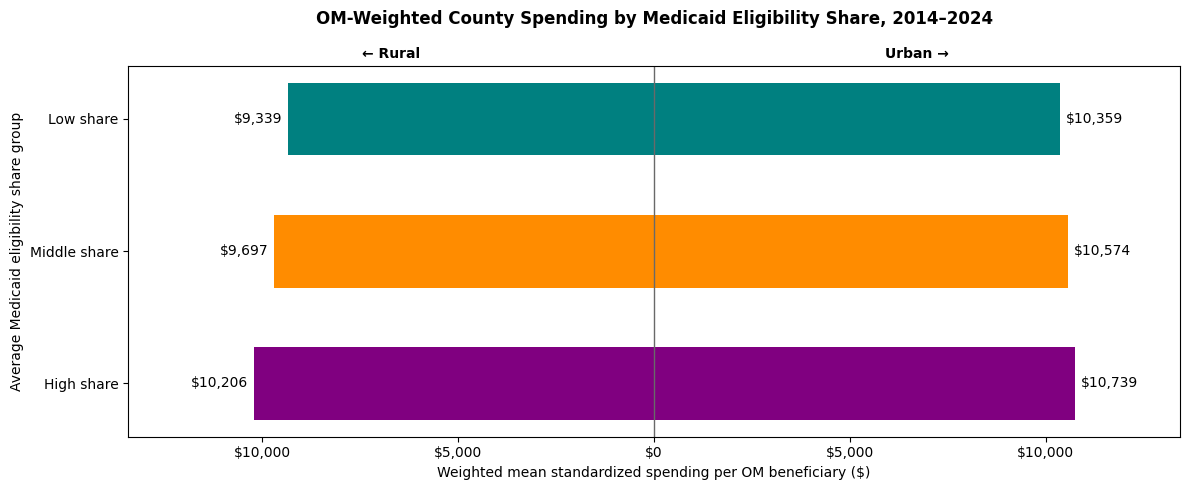

In [ ]:
# Keep named Urban/Rural counties during 2014–2024
county_analysis = county_df[
    county_df["year"].isin(range(2014, 2025)) &
    county_df["rural_urban"].isin(["Urban", "Rural"]) &
    ~county_df["name"].str.endswith("-UNKNOWN", na=False)
].copy()

# Calculate each county's average Medicaid eligibility share
county_groups = county_analysis.groupby(
    ["fips", "rural_urban"]
)["medicaid_pct"].mean().reset_index()

county_groups = county_groups.dropna(subset=["medicaid_pct"])

# Assign fixed Low, Middle, and High groups
county_groups["medicaid_group"] = pd.qcut(
    county_groups["medicaid_pct"],
    q=3,
    labels=["Low share", "Middle share", "High share"]
)

display(
    county_groups.groupby("medicaid_group", observed=True)[
        "medicaid_pct"
    ].agg(["min", "max"]).round(2)
)

# Attach each county's group to its original yearly observations
weighted_data = county_analysis.merge(
    county_groups[["fips", "rural_urban", "medicaid_group"]],
    on=["fips", "rural_urban"],
    how="inner"
)

# Weighted spending requires spending and positive OM beneficiary counts
weighted_data = weighted_data.dropna(
    subset=["spend_pc_std", "benes_om"]
).copy()

weighted_data = weighted_data[
    weighted_data["benes_om"] > 0
].copy()

# Calculate the numerator for the weighted mean
weighted_data["weighted_spending"] = (
    weighted_data["spend_pc_std"] * weighted_data["benes_om"]
)

# Sum across county-years within each group
group_totals = weighted_data.groupby(
    ["medicaid_group", "rural_urban"], observed=True
)[["weighted_spending", "benes_om"]].sum()

group_totals["weighted_mean"] = (
    group_totals["weighted_spending"] / group_totals["benes_om"]
)

# Arrange spending values for the Rural/Urban comparison
spending = group_totals["weighted_mean"].unstack().reindex(
    index=["Low share", "Middle share", "High share"],
    columns=["Rural", "Urban"]
)

print("OM-weighted spending per beneficiary:")
display(spending.round(2))

# Count distinct counties contributing spending observations
print("Counties contributing to each group:")
display(
    weighted_data.groupby(
        ["medicaid_group", "rural_urban"], observed=True
    )["fips"].nunique().unstack()
)

# Plot Rural spending to the left and Urban spending to the right
fig, ax = plt.subplots(figsize=(12, 5))

for position, (group, color) in enumerate(zip(
    spending.index, ["teal", "darkorange", "purple"]
)):
    rural = spending.loc[group, "Rural"]
    urban = spending.loc[group, "Urban"]

    ax.barh(position, -rural, color=color, height=0.55)
    ax.barh(position, urban, color=color, height=0.55)

    # Show positive dollar amounts on both sides.
    ax.text(
        -rural - 150, position, f"${rural:,.0f}",
        ha="right", va="center"
    )
    ax.text(
        urban + 150, position, f"${urban:,.0f}",
        ha="left", va="center"
    )

# Use matching scales on either side of zero.
limit = spending.max().max() * 1.25
ax.set_xlim(-limit, limit)
ax.axvline(0, color="dimgray", linewidth=1)

ticks = [
    tick for tick in ax.get_xticks()
    if -limit <= tick <= limit
]
ax.set_xticks(ticks)
ax.set_xticklabels([f"${abs(tick):,.0f}" for tick in ticks])

ax.set_yticks(range(len(spending)))
ax.set_yticklabels(spending.index)
ax.invert_yaxis()

ax.text(
    0.25, 1.02, "← Rural",
    transform=ax.transAxes, ha="center", fontweight="bold"
)
ax.text(
    0.75, 1.02, "Urban →",
    transform=ax.transAxes, ha="center", fontweight="bold"
)

ax.set_title(
    "OM-Weighted County Spending by Medicaid Eligibility Share, 2014–2024",
    fontweight="bold", pad=30
)
ax.set_xlabel("Weighted mean standardized spending per OM beneficiary ($)")
ax.set_ylabel("Average Medicaid eligibility share group")

plt.tight_layout()
plt.show()

### Interpretation

1. **OM-weighted spending increases with Medicaid eligibility share in both Rural and Urban counties.** Rural spending rises from $9,339 in the low-share group to $10,206 in the high-share group, while Urban spending rises from $10,359 to $10,739. The difference between low- and high-share groups is therefore larger among Rural counties.

2. Urban counties have higher spending in every eligibility group, but the **Rural–Urban gap narrows as Medicaid eligibility increases**: from $1,020 in the low-share group to $877 in the middle-share group and $533 in the high-share group.

3. These patterns show an association between Medicaid eligibility share and overall OM spending, but do not establish causation. Differences in beneficiary health needs, access to care, and other characteristics may contribute.

**CAVEAT:** **Spending covers all OM beneficiaries in each county group, not only those eligible for Medicaid.** Values combine available county-years from 2014–2024, weighted by OM beneficiary counts, and are not adjusted for inflation. The left-hand bars show positive Rural spending amounts; their position does not indicate negative spending.

## Changes in Medicare Beneficiary Composition, 2014–2024

Compare Original Medicare and Medicare Advantage beneficiaries as shares of total national Medicare enrollment across years

/var/folders/47/y3rxj0mn3l74c5r0ythwsbg40000gp/T/ipykernel_47415/2629871260.py:2: DtypeWarning: Columns (222,223) have mixed types. Specify dtype option on import or set low_memory=False.
  enrollment = pd.read_csv(


,year,original_pct,advantage_pct,other_pct
0,2014,58.95,27.90,13.15
3362,2015,57.56,29.55,12.90
6725,2016,56.87,30.44,12.69
10087,2017,55.12,32.00,12.88
13449,2018,53.28,33.50,13.22
16811,2019,51.49,35.14,13.37
20173,2020,49.22,37.86,12.92
23535,2021,46.15,40.86,12.99
26899,2022,43.47,43.52,13.01
30264,2023,40.87,45.82,13.32


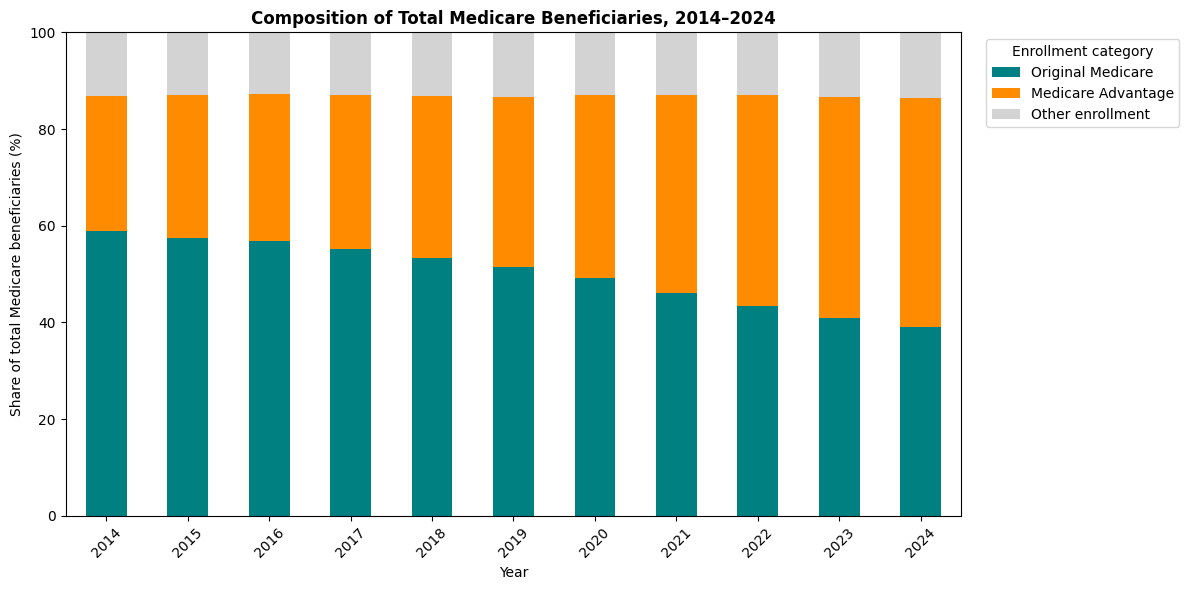

In [14]:
# Read enrollment counts from the raw CMS file.
enrollment = pd.read_csv(
    "../data/raw/Medicare_GV_by_National_State_County_2024.csv"
)

# Keep national observations for all ages.
enrollment = enrollment[
    (enrollment["Geographic Level"] == "National") &
    (enrollment["Age Level"] == "All")
].copy()

# Rename the required columns.
enrollment = enrollment.rename(columns={
    "Year": "year",
    "Total Medicare Beneficiaries": "total",
    "Original Medicare (OM) Beneficiaries": "original",
    "MA Beneficiaries": "advantage"
})

# Remove commas and convert beneficiary counts to numbers.
for column in ["total", "original", "advantage"]:
    enrollment[column] = pd.to_numeric(
        enrollment[column].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

enrollment = enrollment.sort_values("year")

# Calculate each group's percentage of total Medicare beneficiaries.
enrollment["original_pct"] = (
    enrollment["original"] / enrollment["total"] * 100
)
enrollment["advantage_pct"] = (
    enrollment["advantage"] / enrollment["total"] * 100
)

# OM and MA counts do not exhaust the total population under CMS definitions.
# The remainder includes beneficiaries outside these enrollment definitions.
enrollment["other_pct"] = (
    100 - enrollment["original_pct"] - enrollment["advantage_pct"]
)

display(enrollment[
    ["year", "original_pct", "advantage_pct", "other_pct"]
].round(2))

# Show how the composition changes using a 100% stacked bar chart.
ax = enrollment.set_index("year")[
    ["original_pct", "advantage_pct", "other_pct"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["teal", "darkorange", "lightgray"]
)

ax.set_title(
    "Composition of Total Medicare Beneficiaries, 2014–2024",
    fontweight="bold"
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of total Medicare beneficiaries (%)")
ax.set_ylim(0, 100)
ax.legend(
    ["Original Medicare", "Medicare Advantage", "Other enrollment"],
    title="Enrollment category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation: Changes in Medicare Beneficiary Composition

1. **Medicare enrollment composition shifted steadily toward Medicare Advantage between 2014 and 2024.** Original Medicare’s share of total beneficiaries fell from approximately 59% to 39%, while Medicare Advantage’s share rose from about 28% to 47%. Medicare Advantage overtook Original Medicare’s share in 2023 and remained larger in 2024.

2. **The remaining enrollment share stayed relatively stable at approximately 13–14%.** This represents beneficiaries outside the dataset’s full-period OM and MA enrollment definitions, rather than a third Medicare program.

3. This shift matters for our analysis because the spending and hospital-use measures describe Original Medicare beneficiaries. By 2024, that population represented a smaller share of total Medicare enrollment, so our findings should not be interpreted as covering all Medicare beneficiaries. However, the chart alone does not show whether OM beneficiary counts declined or whether changes in enrollment composition caused changes in spending.

**Note:** Percentages use total Medicare beneficiaries as the denominator and may differ from CMS’s published Medicare Advantage participation rate.

## Geographic Dispersion in Original Medicare Spending, 2024

Comparing the distribution of standardized spending per Original Medicare beneficiary across states and counties

/var/folders/47/y3rxj0mn3l74c5r0ythwsbg40000gp/T/ipykernel_47415/4294540030.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


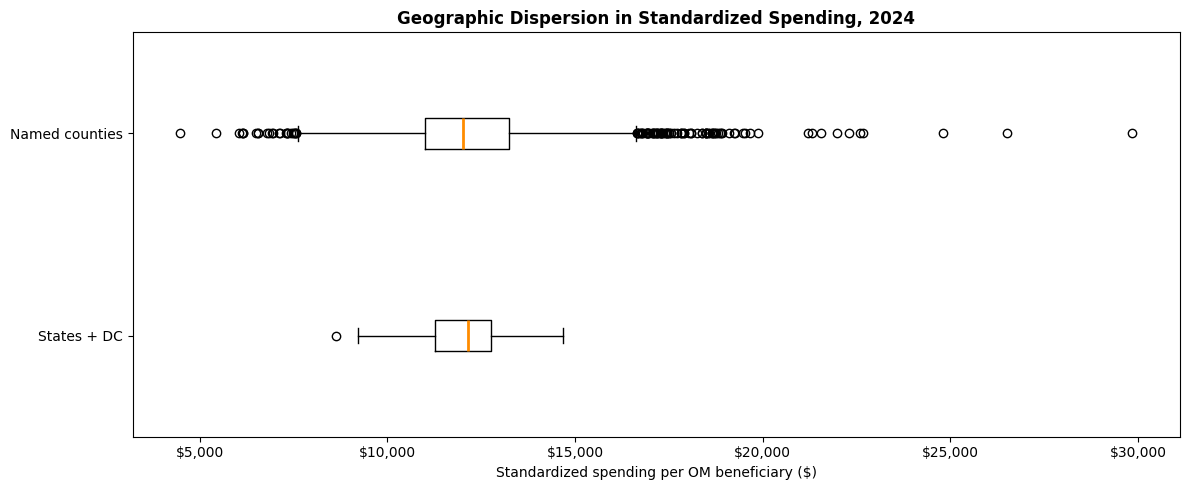

In [15]:
# Select spending values for states and named counties in 2024.
state_spending = state_df[
    state_df["year"] == 2024
]["spend_pc_std"].dropna()

county_spending = county_df[
    (county_df["year"] == 2024) &
    ~county_df["name"].str.endswith("-UNKNOWN", na=False)
]["spend_pc_std"].dropna()

# Draw both distributions on the same spending scale.
fig, ax = plt.subplots(figsize=(12, 5))

ax.boxplot(
    [state_spending, county_spending],
    vert=False,
    labels=["States + DC", "Named counties"],
    medianprops={"color": "darkorange", "linewidth": 2}
)

ax.set_title(
    "Geographic Dispersion in Standardized Spending, 2024",
    fontweight="bold"
)
ax.set_xlabel("Standardized spending per OM beneficiary ($)")

# Format the spending axis as dollars.
ticks = [5000, 10000, 15000, 20000, 25000, 30000]
ax.set_xticks(ticks)
ax.set_xticklabels([f"${value:,.0f}" for value in ticks])

plt.tight_layout()
plt.show()

### Interpretation

1. **States and counties have similar median spending in 2024 12,145 for states and $12,022 for counties - but county spending varies much more widely.** The middle 50% of county values spans $10,996–$13,254, compared with $11,260–$12,757.50 for states.

2. **County spending also has a longer upper tail, with several unusually high values.** Overall, county spending ranges from $4,482 to $29,853, while state spending ranges from 8,622 to $14,680. This suggests that state averages conceal substantial variation within states.